# Informe de Trabajo: Machine Learning Supervisado
## Caso de estudio: Predicción de defectos en producción

**Estudiante:** Joan Schneider Beltrán Delgado
**Asignatura:** Introducción a Machine Learning — CADI, Universidad de Cundinamarca
**Docente:** Ing. Wilson Rojas Reales, PhD(c)
**Fecha:** Octubre de 2026

Este notebook implementa Regresión Logística y cinco algoritmos adicionales de clasificación supervisada (Árbol de Decisión, Random Forest, SVM, KNN y Naive Bayes) sobre el caso de estudio "Predicción de defectos en producción", siguiendo la guía práctica de regresión logística y el material de algoritmos de clasificación de la asignatura (Universidad de Cundinamarca, 2024).

## 1. Descripción del caso

La empresa manufacturera XYZ Inc. necesita anticipar si un lote de producción saldrá defectuoso (1) o no defectuoso (0), a partir de cinco variables del proceso productivo: temperatura de la máquina, presión del sistema, velocidad de producción, horas continuas de operación y nivel de vibración.

Un lote defectuoso implica pérdidas económicas, reprocesos, devoluciones y afectación de la calidad. Por eso el objetivo del modelo no es simplemente acertar la mayoría de las veces, sino ayudar a detectar a tiempo los lotes que realmente van a salir mal; de ahí que el recall sea, según el propio enunciado del caso, la métrica más relevante a estudiar, aunque es importante revisar todas las métricas disponibles.

## 2. Importación de librerías

Se utilizan las librerías estándar para este tipo de ejercicios: `pandas` y `numpy` para el manejo de datos, `matplotlib` para visualización y `scikit-learn` para los modelos y las métricas (Pedregosa et al., 2011; Scikit-learn, 2025).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

## 3. Dataset del proceso productivo

Se simula un conjunto de 60 lotes de producción. Las variables se generan de forma que un lote tiende a salir defectuoso cuando la temperatura y la vibración son altas, la presión es baja y la máquina lleva muchas horas continuas de operación (desgaste), replicando el comportamiento descrito en el enunciado del caso.

In [2]:
n = 60

temperatura = np.random.normal(70, 10, n)       # grados Celsius
presion = np.random.normal(5, 1.2, n)           # bares
velocidad = np.random.normal(100, 15, n)        # unidades/minuto
hora_operacion = np.random.uniform(0, 16, n)    # horas continuas de uso
vibracion = np.random.normal(3, 1, n)           # nivel de vibración (escala 0-10)

# Puntaje de riesgo: combina las variables según su efecto esperado
# sobre la probabilidad de que el lote salga defectuoso.
riesgo = (
    0.05 * (temperatura - 70)
    - 0.6 * (presion - 5)
    + 0.08 * (hora_operacion - 8)
    + 0.7 * (vibracion - 3)
    + np.random.normal(0, 1, n)  # ruido aleatorio del proceso
)

defectuoso = (riesgo > 0.5).astype(int)

df = pd.DataFrame({
    "temperatura": temperatura,
    "presion": presion,
    "velocidad": velocidad,
    "hora_operacion": hora_operacion,
    "vibracion": vibracion,
    "defectuoso": defectuoso,
})

print(df.head(10))
print(f"\nTotal de lotes: {len(df)}")
print(f"Lotes defectuosos (1): {df['defectuoso'].sum()}")
print(f"Lotes no defectuosos (0): {(df['defectuoso'] == 0).sum()}")

   temperatura   presion   velocidad  hora_operacion  vibracion  defectuoso
0    74.967142  4.424991  111.865479        3.123888   3.064280           0
1    68.617357  4.777209   86.359188       11.559234   1.922255           0
2    76.476885  3.672398  121.041915        4.492358   2.284696           1
3    85.230299  3.564552   78.972234        0.389055   3.679598           1
4    67.658466  5.975031  108.802856       10.327557   2.269633           0
5    67.658630  6.627488  132.856834        2.833771   3.216459           0
6    85.792128  4.913588   85.141955       15.047337   3.045572           1
7    77.674347  6.204239   91.505534       15.262857   2.348400           1
8    65.305256  5.433963  101.494770       14.637830   5.143944           1
9    75.425600  4.225856   92.447865        5.922539   3.633919           0

Total de lotes: 60
Lotes defectuosos (1): 22
Lotes no defectuosos (0): 38


## 4. Variables predictoras y división entrenamiento/prueba

Se separan las variables de entrada (X) de la variable objetivo (y), y se divide el conjunto en 70% para entrenamiento y 30% para prueba, manteniendo la proporción de clases (`stratify=y`) dado que las clases no están perfectamente balanceadas (22 lotes defectuosos frente a 38 no defectuosos).

In [3]:
X = df[["temperatura", "presion", "velocidad", "hora_operacion", "vibracion"]]
y = df["defectuoso"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} lotes | Prueba: {len(X_test)} lotes")

Entrenamiento: 42 lotes | Prueba: 18 lotes


## 5. Regresión Logística

La Regresión Logística es el primer algoritmo que exige esta guía práctica. Es un modelo lineal que estima la probabilidad de que un lote pertenezca a la clase "defectuoso", aplicando la función sigmoide sobre una combinación lineal de las variables de entrada (Ferrer, 2024). Es, además, uno de los algoritmos más usados como punto de partida en problemas de clasificación binaria por su simplicidad e interpretabilidad.

In [4]:
modelo_rl = LogisticRegression(max_iter=1000)
modelo_rl.fit(X_train, y_train)
y_pred_rl = modelo_rl.predict(X_test)

print("Coeficientes del modelo (por variable):")
for var, coef in zip(X.columns, modelo_rl.coef_[0]):
    print(f"  {var:16s}: {coef:+.4f}")
print(f"Intercepto: {modelo_rl.intercept_[0]:+.4f}")

Coeficientes del modelo (por variable):
  temperatura     : +0.0688
  presion         : -0.7720
  velocidad       : +0.0037
  hora_operacion  : +0.1683
  vibracion       : +1.3455
Intercepto: -7.5860


Los coeficientes muestran la dirección del efecto de cada variable sobre la probabilidad de defecto: valores positivos en temperatura y vibración empujan la predicción hacia "defectuoso", mientras que la presión actúa en sentido contrario, consistente con el diseño del dataset.

## 6. Algoritmos de clasificación adicionales

Además de la Regresión Logística, la guía pide implementar cinco algoritmos de clasificación adicionales: Árbol de Decisión, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN) y Naive Bayes (Towards Data Science, 2020; Universidad de Cundinamarca, 2024). Cada uno sigue una lógica distinta para separar las clases, lo que permite comparar su desempeño sobre el mismo problema (Machine learning classification model comparison, 2023).

In [5]:
modelos = {
    "Regresión Logística": modelo_rl,
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="linear"),
    "Naive Bayes": GaussianNB(),
}

## 7. Entrenamiento, predicción y métricas por modelo

Para cada modelo se calculan las cuatro métricas principales (accuracy, precisión, recall y F1-score), la validación cruzada de 5 particiones y la matriz de confusión con sus cuatro componentes (TP, TN, FP, FN).

In [6]:
resultados = []

for nombre, modelo in modelos.items():
    print("\n" + "-" * 60)
    print("Modelo:", nombre)
    print("-" * 60)

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cv_scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
    cv_mean = cv_scores.mean()

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "CV Accuracy Promedio": cv_mean,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
    })

    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"Promedio validación cruzada: {cv_mean:.3f}")
    print("\nMatriz de confusión:")
    print(cm)
    print(f"  TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))


------------------------------------------------------------
Modelo: Regresión Logística
------------------------------------------------------------
Accuracy  : 0.778
Precision : 0.800
Recall    : 0.571
F1-score  : 0.667
Promedio validación cruzada: 0.733

Matriz de confusión:
[[10  1]
 [ 3  4]]
  TP: 4  TN: 10  FP: 1  FN: 3

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       0.80      0.57      0.67         7

    accuracy                           0.78        18
   macro avg       0.78      0.74      0.75        18
weighted avg       0.78      0.78      0.77        18


------------------------------------------------------------
Modelo: Árbol de Decisión
------------------------------------------------------------


Accuracy  : 0.444


Precision : 0.333
Recall    : 0.429
F1-score  : 0.375
Promedio validación cruzada: 0.667

Matriz de confusión:
[[5 6]
 [4 3]]
  TP: 3  TN: 5  FP: 6  FN: 4

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.56      0.45      0.50        11
           1       0.33      0.43      0.38         7

    accuracy                           0.44        18
   macro avg       0.44      0.44      0.44        18
weighted avg       0.47      0.44      0.45        18


------------------------------------------------------------
Modelo: Random Forest
------------------------------------------------------------


Accuracy  : 0.722
Precision : 1.000
Recall    : 0.286
F1-score  : 0.444
Promedio validación cruzada: 0.700

Matriz de confusión:
[[11  0]
 [ 5  2]]
  TP: 2  TN: 11  FP: 0  FN: 5

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.69      1.00      0.81        11
           1       1.00      0.29      0.44         7

    accuracy                           0.72        18
   macro avg       0.84      0.64      0.63        18
weighted avg       0.81      0.72      0.67        18


------------------------------------------------------------
Modelo: KNN
------------------------------------------------------------
Accuracy  : 0.667
Precision : 0.667
Recall    : 0.286
F1-score  : 0.400
Promedio validación cruzada: 0.667

Matriz de confusión:
[[10  1]
 [ 5  2]]
  TP: 2  TN: 10  FP: 1  FN: 5

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       

## 8. Tabla comparativa final

In [7]:
df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values(by="Recall", ascending=False).to_string(index=False))

mejor_por_recall = df_resultados.sort_values(by="Recall", ascending=False).iloc[0]
mejor_por_f1 = df_resultados.sort_values(by="F1-score", ascending=False).iloc[0]

print(f"\nMejor modelo según Recall  : {mejor_por_recall['Modelo']} ({mejor_por_recall['Recall']:.3f})")
print(f"Mejor modelo según F1-score: {mejor_por_f1['Modelo']} ({mejor_por_f1['F1-score']:.3f})")

             Modelo  Accuracy  Precision   Recall  F1-score  CV Accuracy Promedio  TP  TN  FP  FN
                SVM  0.833333   0.833333 0.714286  0.769231              0.750000   5  10   1   2
Regresión Logística  0.777778   0.800000 0.571429  0.666667              0.733333   4  10   1   3
  Árbol de Decisión  0.444444   0.333333 0.428571  0.375000              0.666667   3   5   6   4
        Naive Bayes  0.666667   0.600000 0.428571  0.500000              0.700000   3   9   2   4
                KNN  0.666667   0.666667 0.285714  0.400000              0.666667   2  10   1   5
      Random Forest  0.722222   1.000000 0.285714  0.444444              0.700000   2  11   0   5

Mejor modelo según Recall  : SVM (0.714)
Mejor modelo según F1-score: SVM (0.769)


## 9. Gráfica comparativa de métricas

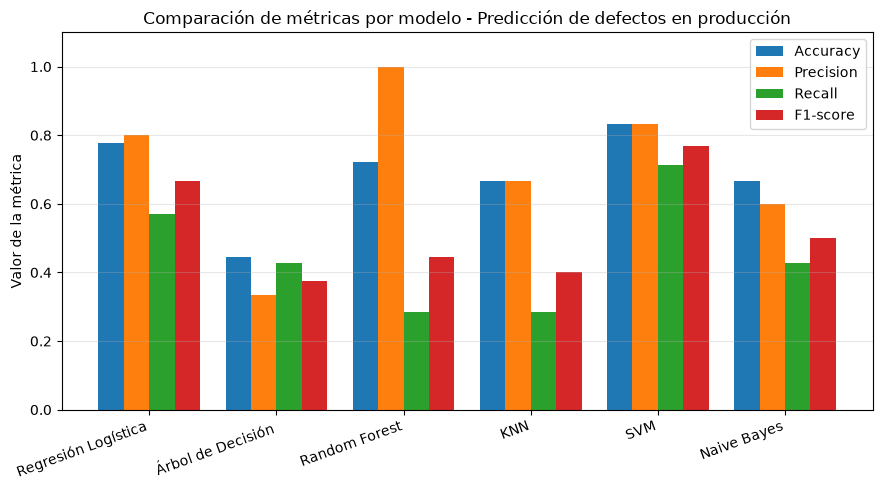

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(df_resultados))
width = 0.2

ax.bar(x_pos - 1.5*width, df_resultados["Accuracy"], width, label="Accuracy")
ax.bar(x_pos - 0.5*width, df_resultados["Precision"], width, label="Precision")
ax.bar(x_pos + 0.5*width, df_resultados["Recall"], width, label="Recall")
ax.bar(x_pos + 1.5*width, df_resultados["F1-score"], width, label="F1-score")

ax.set_xticks(x_pos)
ax.set_xticklabels(df_resultados["Modelo"], rotation=20, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de métricas por modelo - Predicción de defectos en producción")
ax.legend()
ax.grid(True, axis="y", alpha=.3)
plt.tight_layout()
plt.savefig("comparacion_metricas.png", dpi=150)
plt.show()

## 10. Análisis e interpretación de resultados

**Accuracy.** Mide el porcentaje total de lotes clasificados correctamente, sin distinguir el tipo de error. SVM obtuvo el accuracy más alto (0.833), seguido de Regresión Logística (0.778). El Árbol de Decisión quedó muy por debajo del resto (0.444). Como las clases del conjunto de prueba no están balanceadas (11 lotes no defectuosos frente a 7 defectuosos), el accuracy por sí solo puede ser engañoso: un modelo que tienda a predecir "no defectuoso" puede obtener un accuracy aceptable sin ser realmente útil para detectar los lotes problemáticos.

**Precisión.** Responde a la pregunta: de los lotes marcados como defectuosos, ¿cuántos realmente lo eran? Random Forest alcanzó precisión perfecta (1.000), pero su recall fue el más bajo de todos (0.286): fue extremadamente conservador, prediciendo defecto solo en los casos más evidentes. El Árbol de Decisión tuvo la precisión más baja (0.333), generando muchas falsas alarmas.

**Recall.** Es, según el enunciado del caso, la métrica más relevante aquí: mide qué porcentaje de los lotes realmente defectuosos fue detectado. SVM fue el mejor (0.714), detectando 5 de 7 lotes defectuosos. Random Forest y KNN solo detectaron 2 de 7 (0.286), dejando pasar 5 lotes defectuosos cada uno. Un recall bajo es crítico para este negocio: significa que la mayoría de los lotes problemáticos seguirían saliendo de la planta sin ser detectados.

**F1-score.** Combina precisión y recall en un solo número, útil cuando hay tensión entre ambas (como ocurre con Random Forest). SVM obtuvo el F1-score más alto (0.769), reflejando el mejor equilibrio entre ambas métricas.

**Validación cruzada.** Confirma que el desempeño observado no se debe a una partición de datos afortunada o desafortunada. SVM (0.750) y Regresión Logística (0.733) fueron los modelos más estables, mientras que el Árbol de Decisión (0.667) mantuvo un desempeño débil también bajo esta validación, lo que sugiere cierta tendencia al sobreajuste dado el tamaño reducido del conjunto de datos.

**Matriz de confusión e interpretación de errores.** Un falso positivo (predecir "defectuoso" sin que el lote lo sea) genera una revisión o reproceso innecesario, relativamente barato. Un falso negativo (predecir "no defectuoso" cuando el lote sí es defectuoso) es mucho más costoso: el lote llega al cliente, con riesgo de devoluciones y pérdida de reputación. Random Forest y KNN, pese a tener un accuracy razonable, acumulan más falsos negativos (5 cada uno), lo que los vuelve poco recomendables para este problema específico a pesar de la precisión perfecta de Random Forest.

## 11. Conclusión

Aunque Random Forest suele tener fama de ser uno de los algoritmos más robustos, en este ejercicio resultó demasiado conservador para el objetivo del negocio: prefirió casi no arriesgarse a marcar un lote como defectuoso, lo que elevó su precisión a costa de un recall muy bajo. SVM, en cambio, logró el mejor balance entre ambas métricas y fue además el modelo más estable bajo validación cruzada.

Esto confirma la advertencia inicial del caso de estudio: el mejor modelo no es necesariamente el que acierta más veces en total, sino el que mejor ayuda a prevenir que los defectos lleguen al cliente, y esa prioridad se refleja mucho mejor en el recall y el F1-score que en el accuracy por sí solo.

## Referencias

Ferrer, J. (2024, 13 de febrero). *Simplifying logistic regression: A beginner's guide with a real-world practical example*. Medium. https://medium.com/databites/simplifying-logistic-regression-beginners-guide-real-world-example-machine-learning-algorithm-2da80eb7e24f

GitHub. (2026). *Sitio oficial*. https://github.com/

Google Colab. (2026). *Sitio oficial*. https://colab.research.google.com/

Machine learning classification model comparison. (2023). *ScienceDirect*. https://www.sciencedirect.com/science/article/pii/S0038012123000605

Classification and regression trees. (2013). En *Lecture Notes in Computer Science*. Springer. https://link.springer.com/chapter/10.1007/978-3-319-03629-8_10

Matplotlib. (2025). *Sitio oficial*. https://matplotlib.org/

NumPy. (2025). *Guía de inicio*. https://numpy.org/doc/stable/user/quickstart.html

pandas. (2026). *Documentación oficial*. https://pandas.pydata.org/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.

Scikit-learn. (2025). *Tutorial oficial*. https://scikit-learn.org/stable/tutorial/index.html

Towards Data Science. (2020). *Naive Bayes classifier explained*. Medium. https://towardsdatascience.com/naive-bayes-classifier-explained-50f9723571ed/

Universidad de Cundinamarca. (2024). *Algoritmos de clasificación en Machine Learning* [Material de clase]. CADI, Especialización en Inteligencia Artificial.

Universidad de Cundinamarca. (2024). *Guía práctica de regresión logística* [Material de clase]. CADI, Especialización en Inteligencia Artificial.

Universidad de Cundinamarca. (2024). *Machine learning supervisado: regresión logística* [Material de clase]. CADI, Especialización en Inteligencia Artificial.